# Analyze and results
Load rater data (give rathing.csv)


In [33]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pingouin as pg
import os
import scipy.stats as stats

from scipy.stats import chi2
from plotly import express as px
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa



# Constants
RATERS_FILES = [  # Use a constant for file paths
    #'/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Documentations/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/v1/ratings.csv',
    '/Users/cyriltelley/Library/CloudStorage/OneDrive-SharedLibraries-HESSO/Franceschiello Benedetta - 1_Cyril_Telley/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/meri-bene-jaime/ratings.csv',
    '/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Documentations/QC/Evaluation/eye_qc_83/2_ratings/1_training_session/v2/ratings.csv',
]

## Data Loading and Preprocessing Function


In [34]:
# Data Loading and Preprocessing Function
def load_and_preprocess_data(file_paths):
    """Loads, preprocesses, and combines rater data.

    Args:
        file_paths (list): A list of file paths to the rater CSV files.

    Returns:
        pandas.DataFrame: A single DataFrame containing all rater data.
    """
    all_data = []
    for rater_index, file in enumerate(file_paths):
        df = pd.read_csv(file)
        df['rater'] = f'Rater {rater_index + 1}'  # Add rater ID
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df['rating'] = (combined_df['rating1'] + combined_df['rating2']) / 2
    combined_df['sub'] = combined_df['sub'].astype(str)
    combined_df['rater'] = combined_df['rater'].astype('category')
    return combined_df

# Load the data
all_data = load_and_preprocess_data(RATERS_FILES)

## scatter plots - ggplot
Compare ratings between two .csv file

In [ ]:
# --- Faceted Plot Function ---
def create_faceted_plots(metrics, raters_data):
    """Creates faceted plots for multiple metrics across raters."""
    all_data = []

    for rater_index, df in enumerate(raters_data):
        for metric_name, metric_func in metrics.items():
            metric_data = metric_func(df)
            subjects = df['subject'].to_numpy() if 'subject' in df.columns else np.arange(len(metric_data))
            temp_df = pd.DataFrame({
                'Subject': subjects,
                'Value': metric_data,  # Single column for the metric value
                'Rater': f'Rater {rater_index + 1}',
                'Metric': metric_name  # Add a column for the metric name
            })
            all_data.append(temp_df)

    merged_data = pd.concat(all_data, ignore_index=True)
    # check if subject is numeric or not
    is_subject_numeric = all(isinstance(x, (int, float)) for x in merged_data['Subject'].unique())

    # Create the faceted plot
    fig = px.line(
        merged_data,
        x='Subject',
        y='Value',
        color='Rater',
        facet_col='Metric',  # Create a separate subplot for each metric
        facet_col_wrap=4,  # Wrap to 4 columns
        markers=True,
        title="Comparison of All Metrics Across Raters",
        template="plotly_white",
        category_orders={"Metric": list(metrics.keys())} if not is_subject_numeric else {} # keep the same order for metrics plots
    )

    # Customize hover data (same as before, but using 'Value')
    fig.update_traces(
        hovertemplate=(
            f"<b>Subject:</b> %{{x}}<br>"
            f"<b>Value:</b> %{{y}}<br>"
            f"<b>Rater:</b> %{{text}}"
        ),
        text=merged_data['Rater']
    )

    # Update x-axis for all subplots to show all subject
    for axis in fig.layout:
        if "xaxis" in axis:
            fig.layout[axis].tickmode = 'array'
            fig.layout[axis].tickvals = merged_data['Subject'].unique()
            fig.layout[axis].ticktext = merged_data['Subject'].unique()
            # if subject is numeric, force plotly to treat them as numbers and note string name
            if is_subject_numeric :
                fig.layout[axis].type = 'linear'
    
    fig.update_layout(legend_title="Rater")

    fig.show()

# raters_data
raters_data = [all_data[all_data['rater'] == f'Rater {i + 1}'] for i in range(2)]

# Define metrics 
metrics = {
    'Rating': lambda df: np.mean([df['rating1'].to_numpy(), df['rating2'].to_numpy()], axis=0),
    'Rating 1': lambda df: df['rating1'].to_numpy(),
    'Rating 2': lambda df: df['rating2'].to_numpy(),
    'Blur': lambda df: df['blur'].to_numpy(),
    'Noise': lambda df: df['noise'].to_numpy(),
    'Motion': lambda df: df['motion'].to_numpy(),
    'BgAir': lambda df: df['bgair'].to_numpy(),
    'Eyes Closed': lambda df: np.where(df['artifacts'].to_numpy() == "['eyes-open']", 1, 0),
}
create_faceted_plots(metrics, raters_data)

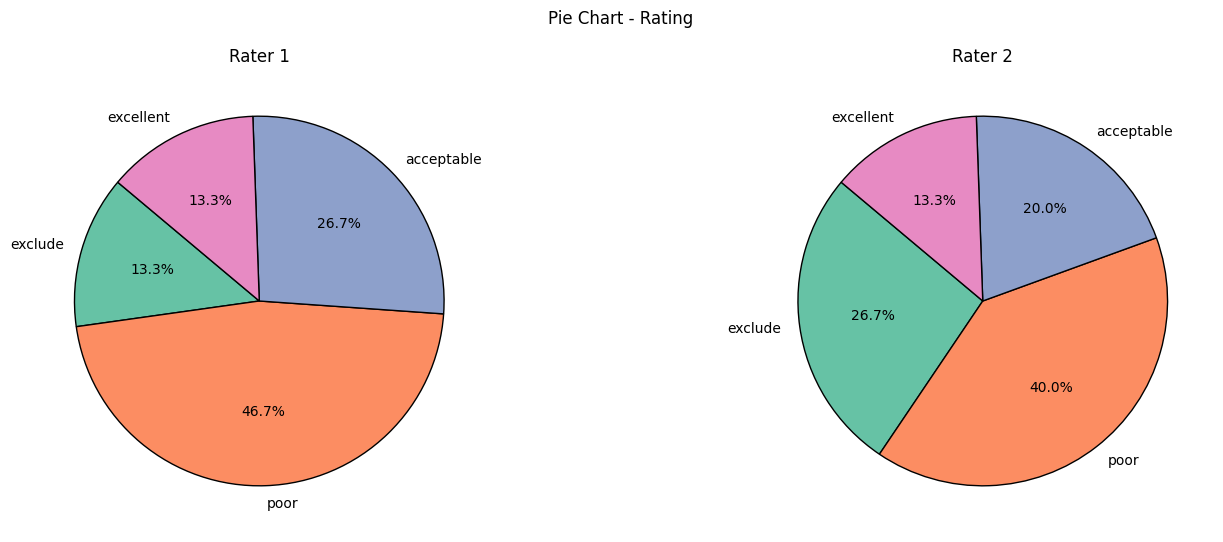

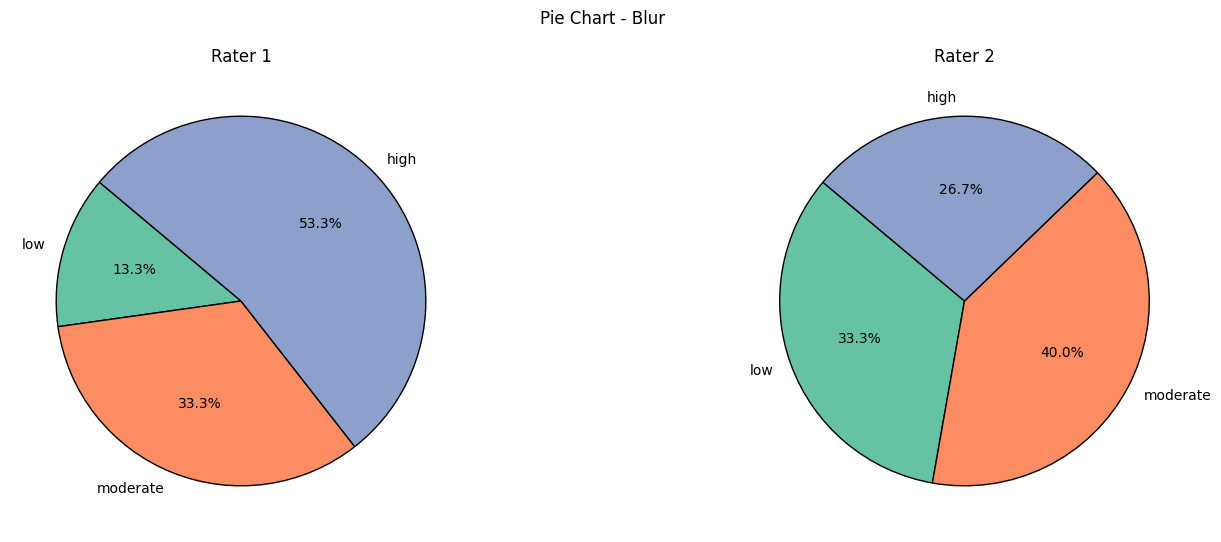

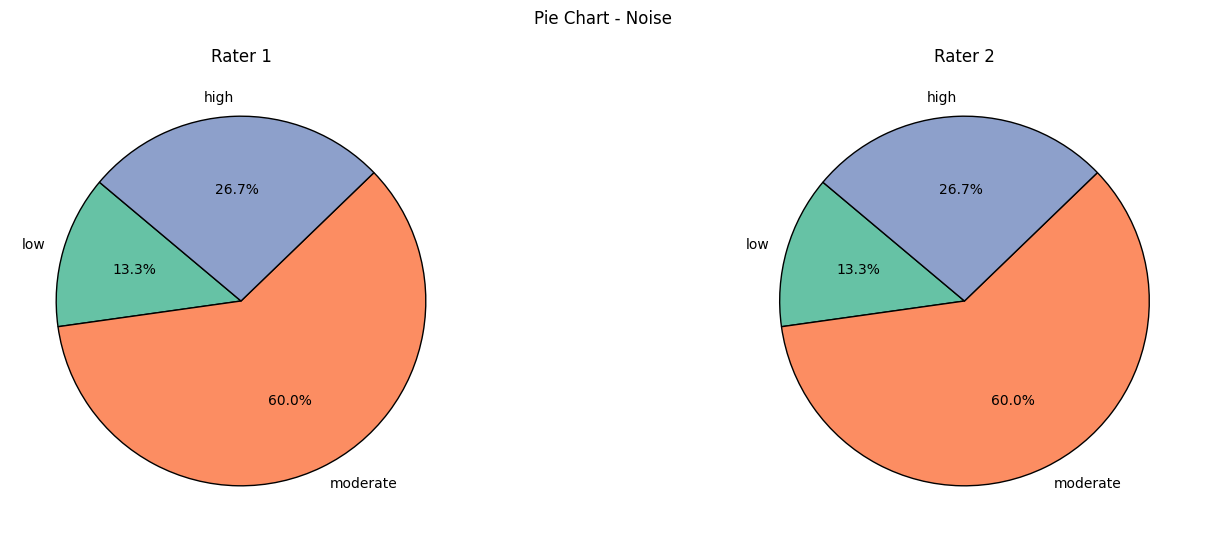

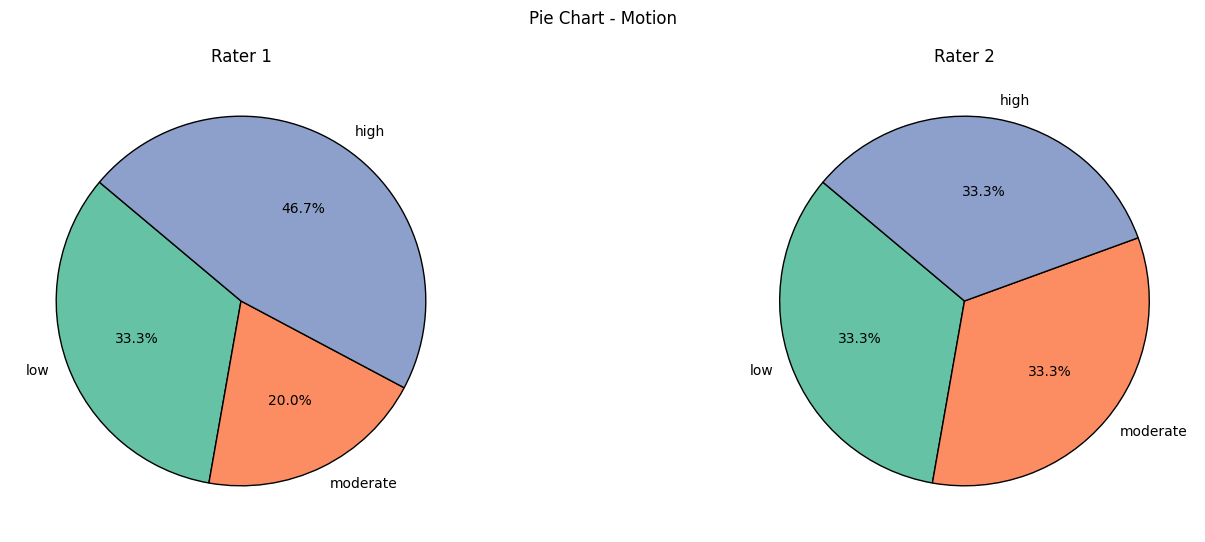

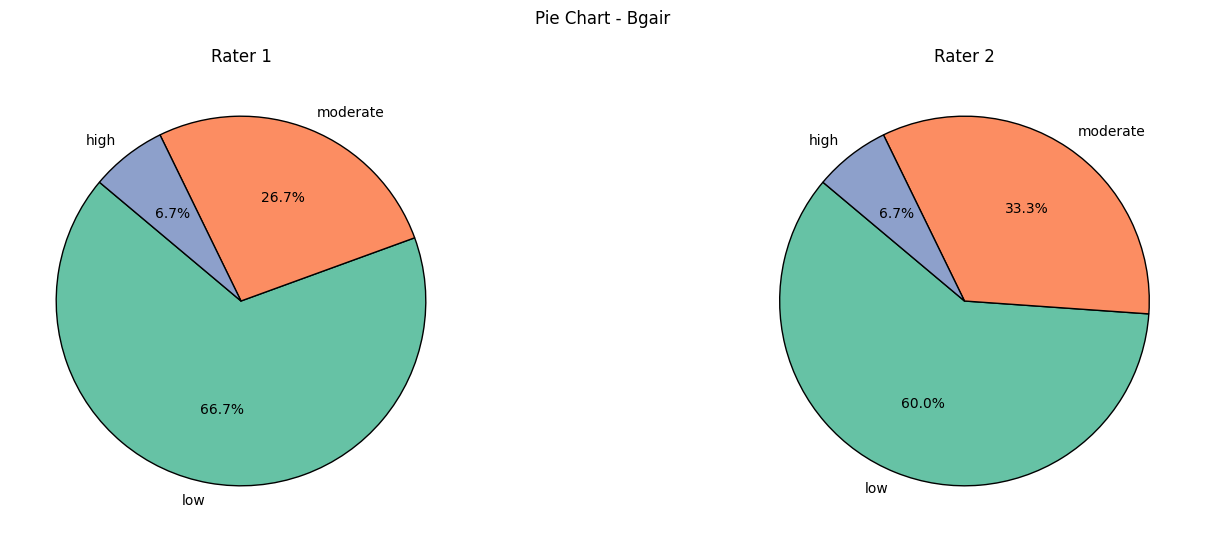

In [36]:
# --- Pie Plot Function ---
def pie_plot(metrics, raters_data):



    # Colors for 4 and 3 categories (more homogeneous palette)
    colors_map = {
        4: ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'],
        3: ['#66c2a5', '#fc8d62', '#8da0cb']
    }

    # Threshold below which labels are not displayed
    LABEL_THRESHOLD = 5  # Percent

    # Load data


    # Generate pie charts for each metric
    for metric_name, categories in metrics.items():
        num_categories = len(categories)
        colors = colors_map[num_categories]

        fig, axes = plt.subplots(1, len(raters_data), figsize=(8 * len(raters_data), 6))
        
        if len(raters_data) == 1:  # Handle single subplot case
            axes = [axes]

        for i, (rater_data, ax) in enumerate(zip(raters_data, axes)):
            counts = [rater_data[metric_name].to_list().count(cat) for cat in categories]
            total = sum(counts)
            percentages = [(count / total) * 100 for count in counts] if total > 0 else [0] * len(counts)
            
            # Filter labels below threshold
            filtered_labels = [
                f"{categories[idx]}" if percentages[idx] >= LABEL_THRESHOLD else ""
                for idx in range(len(categories))
            ]
            
            ax.pie(
                counts,
                labels=filtered_labels,
                autopct=lambda p: f'{p:.1f}%' if p >= LABEL_THRESHOLD else '',  # Hide small slices
                startangle=140,
                colors=colors,
                wedgeprops={'edgecolor': 'black'}  # Add edge color for better visibility
            )
            ax.set_title(f'Rater {i + 1}')
            ax.set_aspect('equal')  # Ensures equal aspect ratio for all subplots
        
        # Adjust layout manually to prevent size mismatch
        fig.subplots_adjust(left=0.1, right=0.9, wspace=0.3)
        fig.suptitle(f'Pie Chart - {metric_name.replace("_text", "").capitalize()}')
        fig.set_facecolor('white')
        
        plt.show()

# Define metrics (same)
# Define metrics and categories
metrics = {
    'rating_text': ['exclude', 'poor', 'acceptable', 'excellent'],
    'blur_text': ['low', 'moderate', 'high'],
    'noise_text': ['low', 'moderate', 'high'],
    'motion_text': ['low', 'moderate', 'high'],
    'bgair_text': ['low', 'moderate', 'high']
}

# Convert text categories to numerical values
pie_plot(metrics, raters_data)

## Mixed-Effects Model Function


In [37]:
# Mixed-Effects Model Function
def fit_mixed_model(data, formula, groups, re_formula=None):
    """Fits a linear mixed-effects model.

    Args:
        data (pd.DataFrame): The input DataFrame.
        formula (str): The model formula (e.g., "rating ~ blur + noise").
        groups (str): The grouping variable for random intercepts (e.g., "sub").
        re_formula (str, optional): Random effects formula. Defaults to None.

    Returns:
        statsmodels.regression.mixed_linear_model.MixedLMResults: Fitted model results.
    """
    model = smf.mixedlm(formula, data=data, groups=groups, re_formula=re_formula)
    result = model.fit()
    return result

def likelihood_ratio_test(result_full, result_reduced):
    """Performs a likelihood ratio test between two nested models.

    Args:
        result_full (MixedLMResults): Results of the full model.
        result_reduced (MixedLMResults): Results of the reduced model.

    Returns:
        tuple: (lrt_statistic, p_value)
    """
    lrt = 2 * (result_full.llf - result_reduced.llf)
    p_value = chi2.sf(lrt, 1)  # 1 degree of freedom for comparing models with/without rater RE
    return lrt, p_value

## Model Fitting and Selection

--- Trying Full Model (with Rater RE) ---
                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      rating  
No. Observations:      30           Method:                  REML    
No. Groups:            15           Scale:                   0.0246  
Min. group size:       2            Log-Likelihood:          -19.4473
Max. group size:       2            Converged:               Yes     
Mean group size:       2.0                                           
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   3.614    0.264 13.694 0.000  3.097  4.132
blur                       -0.515    0.245 -2.098 0.036 -0.996 -0.034
noise                      -0.217    0.158 -1.368 0.171 -0.527  0.094
motion                     -0.260    0.106 -2.465 0.014 -0.467 -

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning:

Retrying MixedLM optimization with lbfgs

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



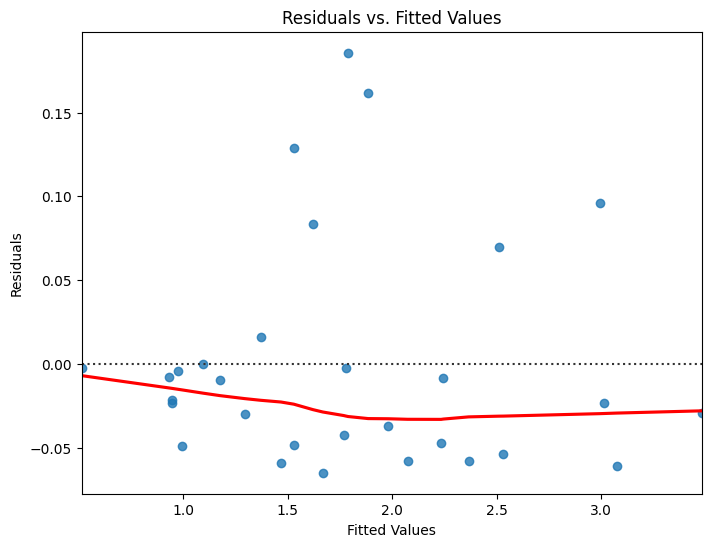

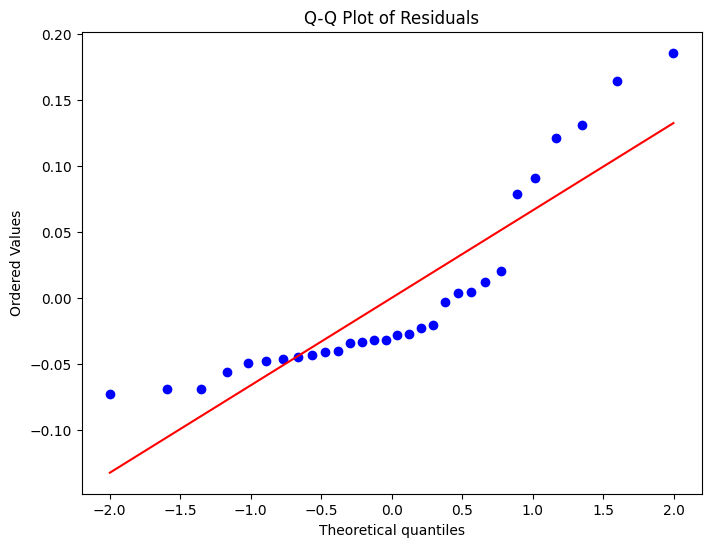

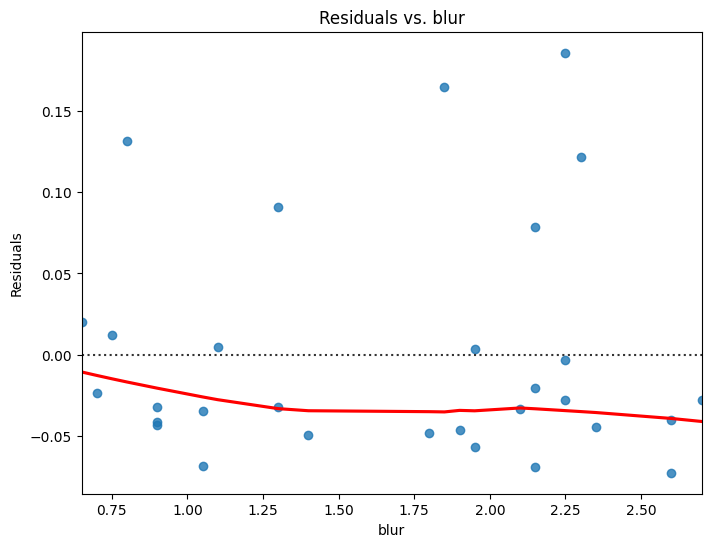

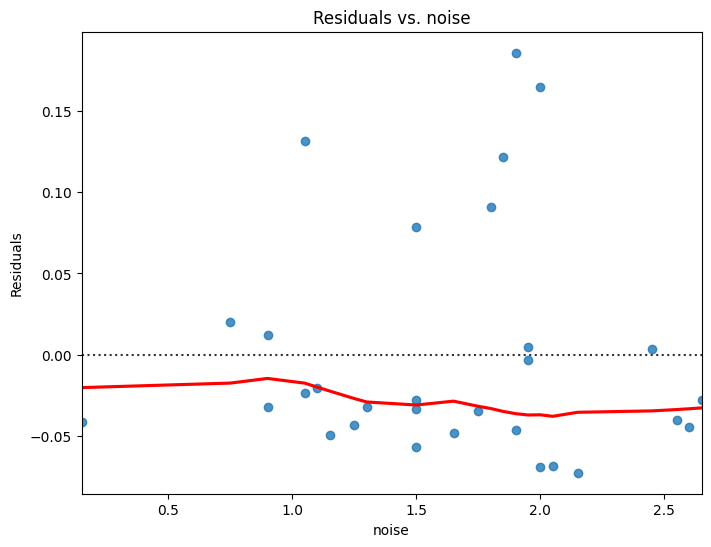

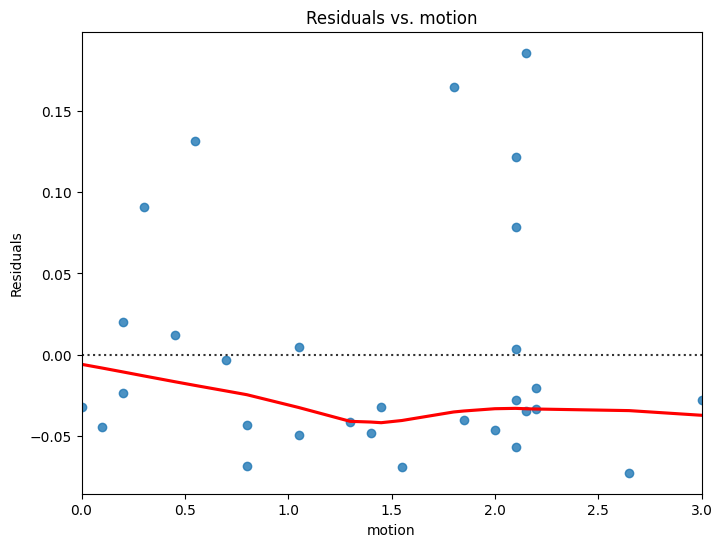

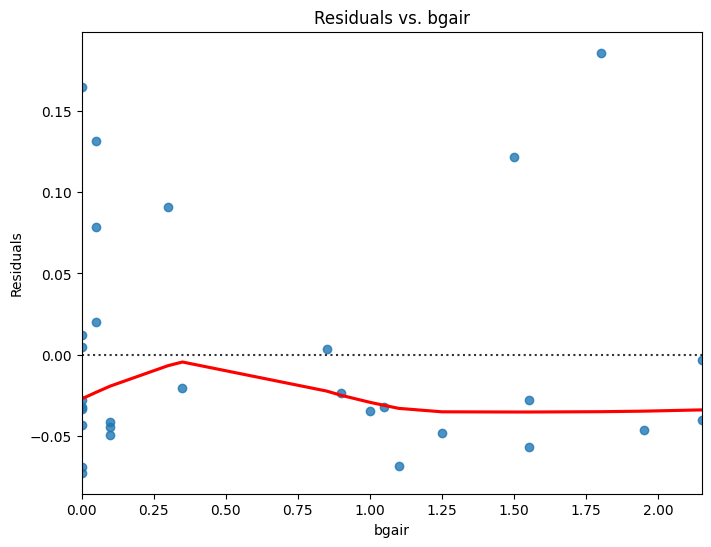

In [38]:
'''
# --- Model Fitting and Selection ---
# Simplified Model
model_simple = "rating ~ blur + noise + motion + bgair"
result_simple = smf.mixedlm(model_simple, data=all_data, groups="sub").fit()
print("\n--- Simplified Model (No Rater RE) ---")
print(result_simple.summary())

# --- Interpretation and Predominant Artifact(s) ---
# (The interpretation code from the previous response, but using result_simple)
print("\n--- Interpretation and Predominant Artifact(s) ---")

# Check for Significance
significant_artifacts = []
for name, pval in result_simple.pvalues.items():  # Use result_simple
    if name in ['blur', 'noise', 'motion', 'bgair'] and pval < 0.05:
        significant_artifacts.append((name, result_simple.params[name]))

# Identify Predominant Artifact(s)
if significant_artifacts:
    significant_artifacts.sort(key=lambda x: abs(x[1]), reverse=True)
    print("Significant artifacts (in order of influence):")
    for name, coef in significant_artifacts:
        print(f"  - {name}: Coefficient = {coef:.3f}")

    predominant_artifact = significant_artifacts[0][0]
    print(f"\nThe predominant artifact is: {predominant_artifact}")
else:
    print("No artifacts have a statistically significant effect on rating.")
'''

# Full Model (with rater random effect)

print("--- Trying Full Model (with Rater RE) ---")
try:
    model_full = smf.mixedlm("rating ~ blur + noise + motion + bgair", data=all_data, groups="sub", re_formula="~rater")
    result_full = model_full.fit()
    print(result_full.summary())
    full_model_converged = True  # Flag to indicate if the full model converged
except Exception as e:
    print(f"Full model failed to converge: {e}")
    result_full = None  # Set result_full to None if it fails
    full_model_converged = False

# 2. Simplified Model (no rater random effect) - Always fit this for comparison
print("\n--- Trying Simplified Model (No Rater RE) ---")
model_simple = smf.mixedlm("rating ~ blur + noise + motion + bgair", data=all_data, groups="sub")
result_simple = model_simple.fit()
print(result_simple.summary())

# 3. Likelihood Ratio Test (ONLY if the full model converged)
if full_model_converged:
    lrt, p_value = likelihood_ratio_test(result_full, result_simple)
    print(f"\nLikelihood Ratio Test: LRT = {lrt:.3f}, p-value = {p_value:.4f}")

    # Choose the best model based on LRT AND convergence
    if p_value > 0.05:
        print("\nUse the simplified model (no rater random effect).")
        final_model = result_simple
    else:
        print("\nUse the full model (with rater random effect).")
        final_model = result_full
else:
    print("\nFull model did not converge. Using simplified model.")
    final_model = result_simple  # Use the simplified model if the full model failed


print("\n--- Final Model Summary ---")
print(final_model.summary())

# --- Interpretation and Predominant Artifact(s) ---
print("\n--- Interpretation and Predominant Artifact(s) ---")

significant_artifacts = []
for name, pval in final_model.pvalues.items():
    if name in ['blur', 'noise', 'motion', 'bgair'] and pval < 0.05:
        significant_artifacts.append((name, final_model.params[name]))

if significant_artifacts:
    significant_artifacts.sort(key=lambda x: abs(x[1]), reverse=True)
    print("Significant artifacts (in order of influence):")
    for name, coef in significant_artifacts:
        print(f"  - {name}: Coefficient = {coef:.3f}")
    predominant_artifact = significant_artifacts[0][0]
    print(f"\nThe predominant artifact is: {predominant_artifact}")
else:
    print("No artifacts have a statistically significant effect on rating.")

# --- Model Diagnostics (for the final model) ---
# Residuals vs. Fitted Values
plt.figure(figsize=(8, 6))
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

# Q-Q Plot of Residuals
plt.figure(figsize=(8, 6))
stats.probplot(final_model.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Residuals vs. Predictors
for predictor in ['blur', 'noise', 'motion', 'bgair']:
    plt.figure(figsize=(8, 6))
    sns.residplot(x=all_data[predictor], y=final_model.resid, lowess=True, line_kws={'color': 'red'})
    plt.xlabel(predictor)
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. {predictor}")
    plt.show()

## Model Diagnostics


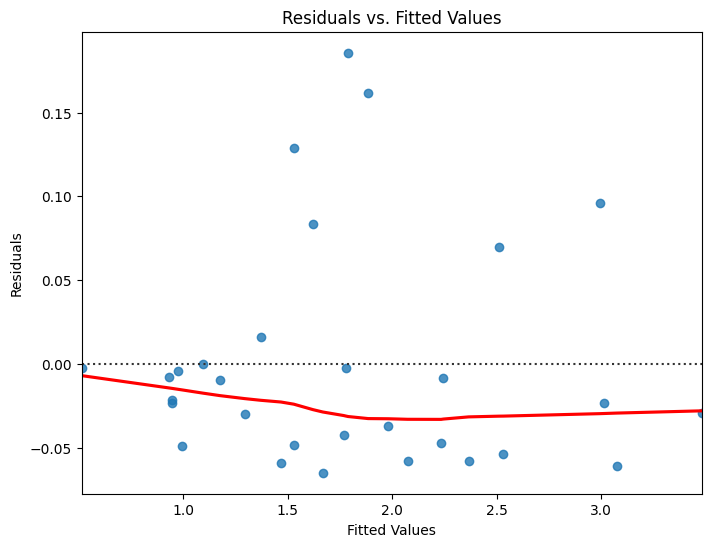

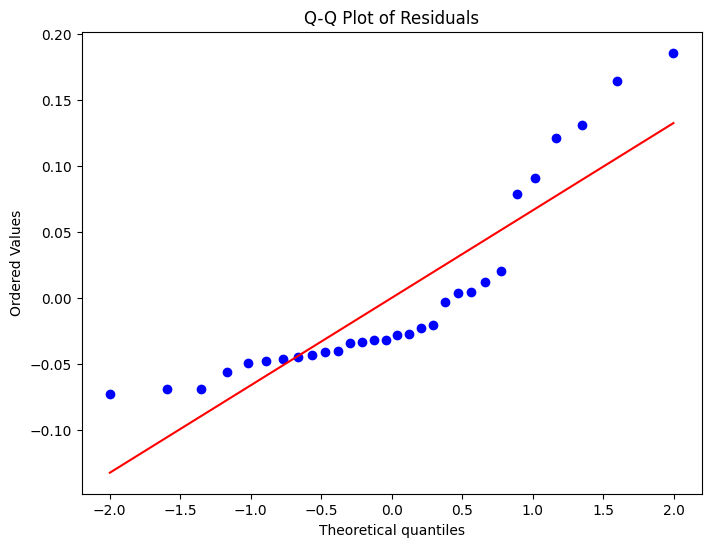

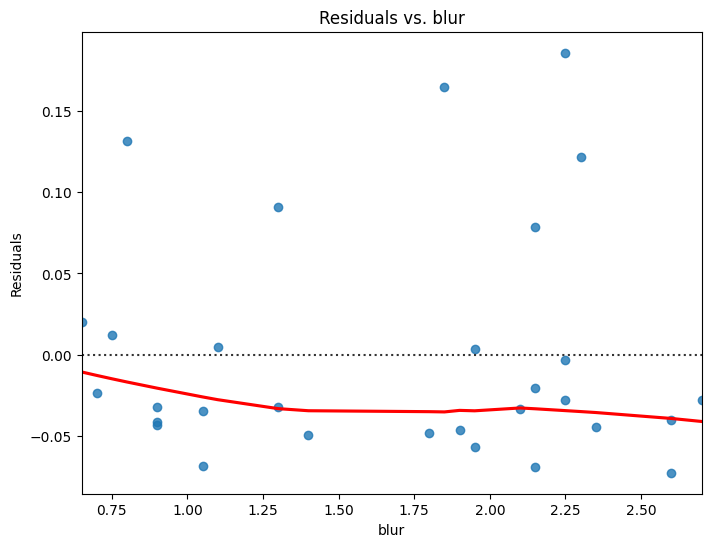

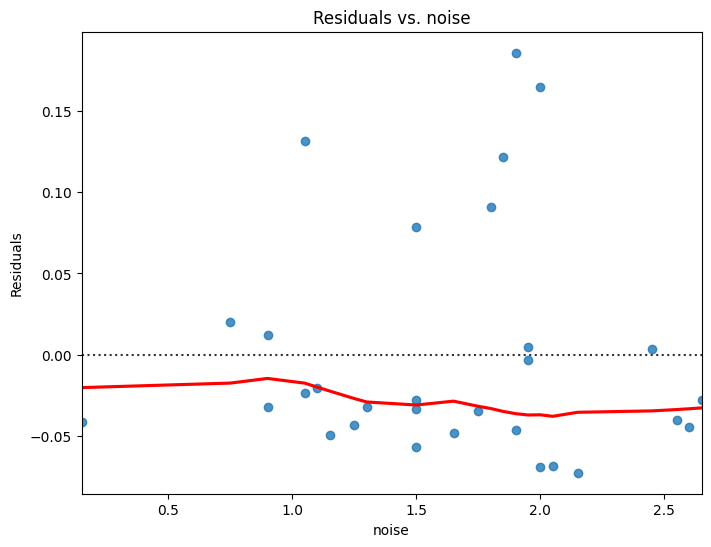

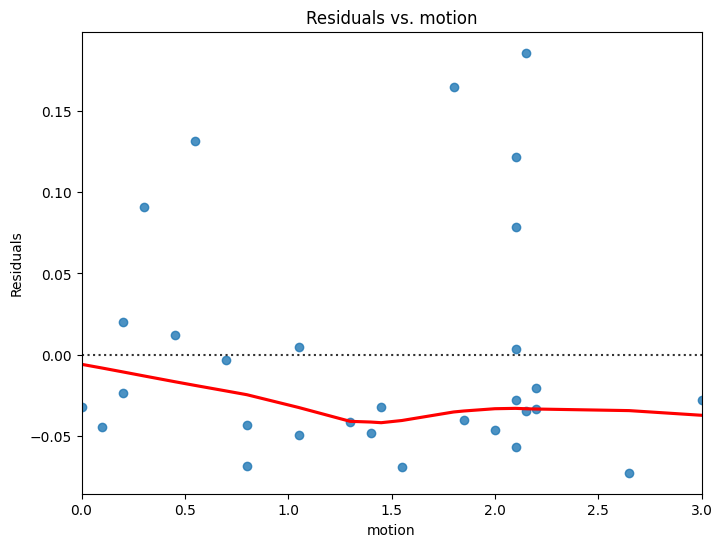

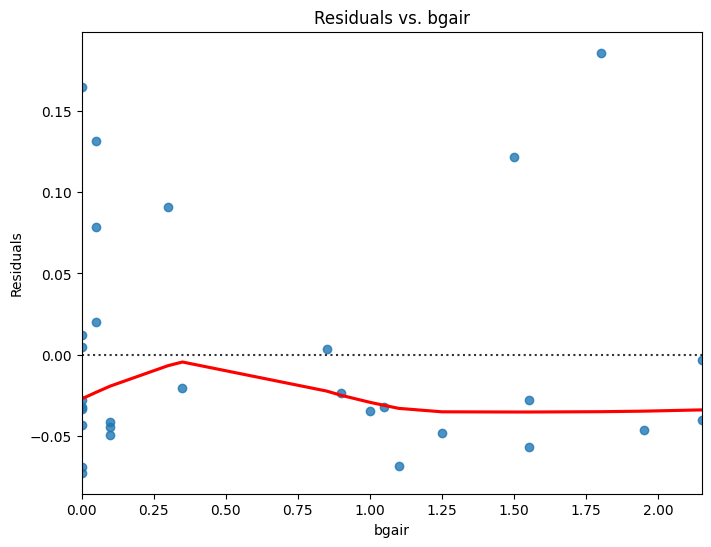

In [39]:
# --- Model Diagnostics (for the final model) ---
import scipy.stats as stats #Ensure import

def plot_residuals(model, data):
  """
  Plot residuals vs fitted, QQ-plot and residuals vs predictors.
  """
  # Residuals vs. Fitted Values
  plt.figure(figsize=(8, 6))
  sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'red'})
  plt.xlabel("Fitted Values")
  plt.ylabel("Residuals")
  plt.title("Residuals vs. Fitted Values")
  plt.show()

  # Q-Q Plot of Residuals
  plt.figure(figsize=(8, 6))
  stats.probplot(model.resid, dist="norm", plot=plt)
  plt.title("Q-Q Plot of Residuals")
  plt.show()

  # Residuals vs. Predictors
  for predictor in ['blur', 'noise', 'motion', 'bgair']:
      plt.figure(figsize=(8, 6))
      sns.residplot(x=data[predictor], y=model.resid, lowess=True, line_kws={'color': 'red'})
      plt.xlabel(predictor)
      plt.ylabel("Residuals")
      plt.title(f"Residuals vs. {predictor}")
      plt.show()

plot_residuals(final_model, all_data)

## Correlation Matrix

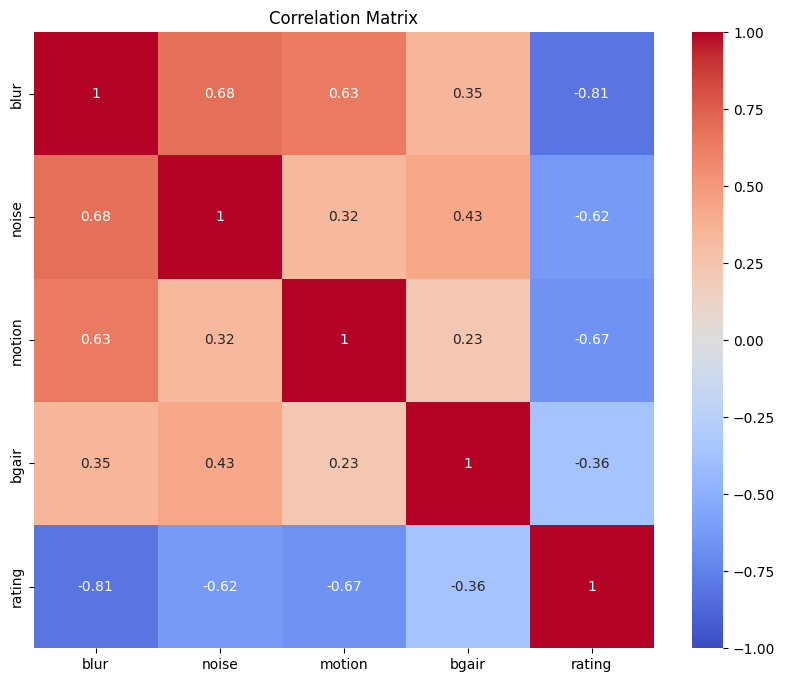

In [40]:
# --- Correlation Matrix (Optional) ---
def plot_correlation_matrix(data, variables):
    """Plots the correlation matrix for the specified variables."""
    correlation_matrix = data[variables].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Matrix')
    plt.show()

plot_correlation_matrix(all_data, ['blur', 'noise', 'motion', 'bgair', 'rating'])

correlation matrix

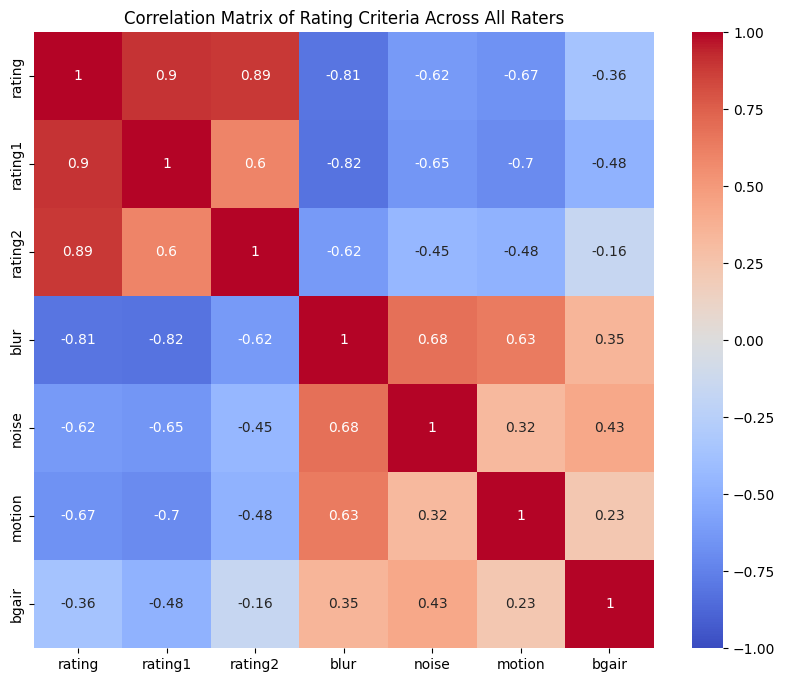

In [41]:

# Load data for all raters
raters_data = [pd.read_csv(file) for file in RATERS_FILES]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine all raters' data into a single DataFrame
combined_data = pd.concat(raters_data, ignore_index=True)

# Select the rating criteria columns
rating_criteria = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Compute the correlation matrix
correlation_matrix = combined_data[rating_criteria].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Rating Criteria Across All Raters')
plt.show()

ICC(A,1) + Cohen's Kappa (for 2 raters)

* ICC(A,1) is sensitive to individual rater differences and can be misleading when many 0s dominate

* Cohen's Kappa measures the agreement on binary sets

In [42]:
# Load data for all raters
raters_data = [pd.read_csv(file) for file in RATERS_FILES]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,1) and Cohen's Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,1)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2"]  # ICC(A,1) corresponds to ICC2 in pingouin
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]  # Extract confidence interval tuple
    print(f"\nMetric: {metric_name} - ICC(A,1): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")
    
    # Cohen's Kappa
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data] # Convert each rater's ratings to binary (0 = absent, 1+ = present)
    for i in range(len(binary_data)):
        for j in range(i + 1, len(binary_data)):
            kappa = cohen_kappa_score(binary_data[i], binary_data[j])
            if np.isnan(kappa):
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: all non-zero ratings (NaN)")
            else:
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: {kappa:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,1): 0.841 [0.550, 0.950] CI95%
Metric: rating - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: rating1 - ICC(A,1): 0.932 [0.790, 0.980] CI95%
Metric: rating1 - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: rating2 - ICC(A,1): 0.668 [0.270, 0.870] CI95%
Metric: rating2 - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: blur - ICC(A,1): 0.702 [0.140, 0.900] CI95%
Metric: blur - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: noise - ICC(A,1): 0.418 [-0.090, 0.760] CI95%
Metric: noise - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: motion - ICC(A,1): 0.448 [-0.060, 0.770] CI95%
Metric: motion - Cohen's Kappa Rater 1 vs Rater 2: 0.000

Metric: bgair - ICC(A,1): 0.775 [0.460, 0.920] CI95%
Metric: bgair - Cohen's Kappa Rater 1 vs Rater 2: 0.299

Eyes open agreement: 93.33% of cases


/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:758: RuntimeWarning:

invalid value encountered in scalar 

ICC(A,k) + Fleiss' Kappa (for >2 raters)

* ICC(A,k) accounts for multiple raters and gives a more stable estimate of agreement

* Fleiss' Kappa replaces Cohen's for multi-rater agreement

In [43]:

# Load data for all raters
raters_data = [pd.read_csv(file) for file in RATERS_FILES]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,k) and Fleiss' Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,k)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2k"]  # Use ICC(A,k) instead of ICC(A,1)
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]
    print(f"\nMetric: {metric_name} - ICC(A,k): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")

    # Convert ratings to binary (0 = absent, 1+ = present)
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data]

    # Construct contingency table for Fleiss' Kappa
    num_subjects = len(binary_data[0])  # Number of items rated
    num_raters = len(binary_data)       # Number of raters
    category_counts = np.zeros((num_subjects, 2))  # Two categories: 0 (absent), 1 (present)

    for subject_idx in range(num_subjects):
        for rater_idx in range(num_raters):
            category_counts[subject_idx, binary_data[rater_idx][subject_idx]] += 1

    # Compute Fleiss' Kappa
    kappa_fleiss = fleiss_kappa(category_counts)
    print(f"Metric: {metric_name} - Fleiss' Kappa: {kappa_fleiss:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,k): 0.913 [0.710, 0.970] CI95%
Metric: rating - Fleiss' Kappa: nan

Metric: rating1 - ICC(A,k): 0.965 [0.890, 0.990] CI95%
Metric: rating1 - Fleiss' Kappa: nan

Metric: rating2 - ICC(A,k): 0.801 [0.430, 0.930] CI95%
Metric: rating2 - Fleiss' Kappa: nan

Metric: blur - ICC(A,k): 0.825 [0.250, 0.950] CI95%
Metric: blur - Fleiss' Kappa: nan

Metric: noise - ICC(A,k): 0.590 [-0.200, 0.860] CI95%
Metric: noise - Fleiss' Kappa: nan

Metric: motion - ICC(A,k): 0.619 [-0.130, 0.870] CI95%
Metric: motion - Fleiss' Kappa: -0.034


/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/Users/cyriltelley/Desktop/MSE/Second_semester/PA-MReye/Codes/.venv/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide




Metric: bgair - ICC(A,k): 0.873 [0.630, 0.960] CI95%
Metric: bgair - Fleiss' Kappa: 0.206

Eyes open agreement: 93.33% of cases
